## Бізнес-контекст
Компанія MediScan AI розробляє систему для аналізу рентген-знімків.
Ви маєте провести дослідження популярних архітектур CNN і спробувати використати переднавчену модель для розпізнавання зображень.

## Завдання 1
Вивчіть три класичні архітектури: LeNet, AlexNet, ResNet. Коротко опишіть їхні відмінності у вигляді таблиці:

| Архітектура | Кількість шарів | Особливості | Застосування |
| :--- | :--- | :--- | :--- |
| LeNet | 7 шарів (5 згорткових та 2 повнозв'язні) | Впровадження концепції згорткових нейромереж. | Розпізнавання простих рукописних цифр (наприклад, поштові індекси) |
| AlexNet | 8 шарів (5 згорткових та 3 повнозв'язні) | Використання ReLU (для швидшого навчання) та Dropout (проти перенавчання) | Масштабна класифікація кольорових зображень (ImageNet) |
| ResNet | Глибока (від 18 до 152 шарів і більше) | Використання "пропускних зв'язків" (Skip Connections), які вирішують проблему зникнення градієнтів. | Високоточне розпізнавання, сегментація зображень, медичні дослідження |

## Завдання 2
Завантажте датасет CIFAR-10 з torchvision.datasets.
 - Виконайте нормалізацію.
 - Створіть DataLoader.
 - Перевірте структуру одного батча (розмір, форма, тип даних).



In [1]:
import torch
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),(0.5, 0.5, 0.5))
])

train_dataset = datasets.CIFAR10(root='data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='data', train=False, download=True, transform=transform)

/home/antik/repos/PythonAi/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [2]:
from torch.utils.data import DataLoader
batch_size = 4
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)
print(len(train_loader), len(test_loader))

12500 2500


In [3]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    trimg = np.transpose(npimg, (1, 2, 0))
    plt.imshow(trimg)
    plt.show()
    

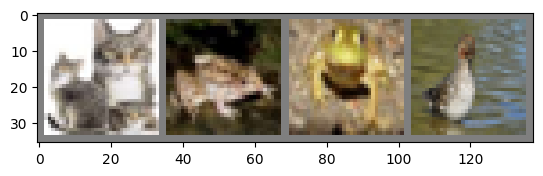

['Cats', 'Frogs', 'Frogs', 'Birds']


In [4]:
import torchvision
train_iter = iter(train_loader)
images, labels = next(train_iter)
imshow(torchvision.utils.make_grid(images))
classes = [
    "Airplanes",
    "Cars",
    "Birds",
    "Cats",
    "Deer",
    "Dogs",
    "Frogs",
    "Horses",
    "Ships",
    "Trucks"
]
print([classes[label] for label in labels])

## Завдання 3
Побудуйте просту мережу на основі архітектури LeNet і навчіть її 5 епох.
 - Порівняйте точність з архітектурою ResNet18 (переднавчена).
 - Використовуйте transfer learning: заморозьте ваги базових шарів.

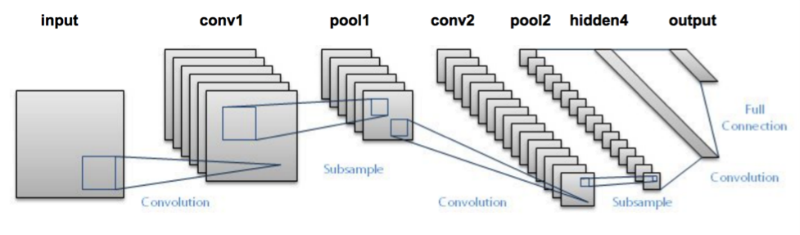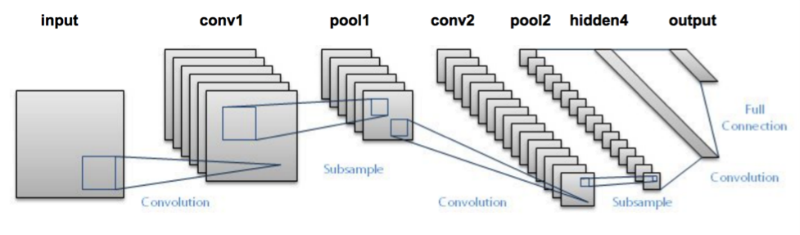

In [5]:
import torch.nn as nn
import torch.nn.functional as F

class LeNet5(nn.Module):
    def __init__(self, classes_count=10):
        super(LeNet5, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, classes_count)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = x.view(-1, 16 * 5 * 5)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x

lenet5 = LeNet5()
print(lenet5)

LeNet5(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
  (relu): ReLU()
)


In [6]:
loss_f = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(lenet5.parameters(), lr=0.001)
epochs = 5
losses = []

for epoch in range(epochs):
    total_loss = 0.0  # загальні втрати за епоху
    for images, labels in train_loader:
        optimizer.zero_grad()
        output = lenet5(images)
        loss = loss_f(output, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    losses.append(total_loss)
    print(f"Epoch: {epoch+1}, Loss: {total_loss}")

Epoch: 1, Loss: 18881.95888441801
Epoch: 2, Loss: 15530.373007457703
Epoch: 3, Loss: 14234.938135871664
Epoch: 4, Loss: 13463.930087406188
Epoch: 5, Loss: 12825.196887464728


In [7]:
correct = 0
total = 0
mis = []

with torch.no_grad():
    for images, labels in test_loader :
        output = lenet5(images)
        _, predicted = torch.max(output, 1)
        total += len(labels)
        correct += (predicted == labels).sum().item()
        for i in range(len(labels)) :
            if predicted[i] != labels[i] :
                mis.append({
                    "label": labels[i],
                    "predicted": predicted[i],
                    "image": images[i]
                })
print(len(mis))

3872


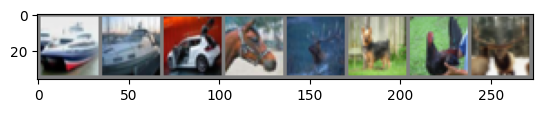

True: Ships, Predicted: Airplanes
True: Ships, Predicted: Cars
True: Cars, Predicted: Cats
True: Horses, Predicted: Cats
True: Deer, Predicted: Birds
True: Dogs, Predicted: Frogs
True: Birds, Predicted: Dogs
True: Deer, Predicted: Cats


In [8]:
from IPython.display import Markdown as md
imshow(torchvision.utils.make_grid([mis[i]["image"] for i in range(8) ]))

for i in range(8):
    true_class = classes[mis[i]["label"]]
    pred_class = classes[mis[i]["predicted"]]
    print(f"True: {true_class}, Predicted: {pred_class}")

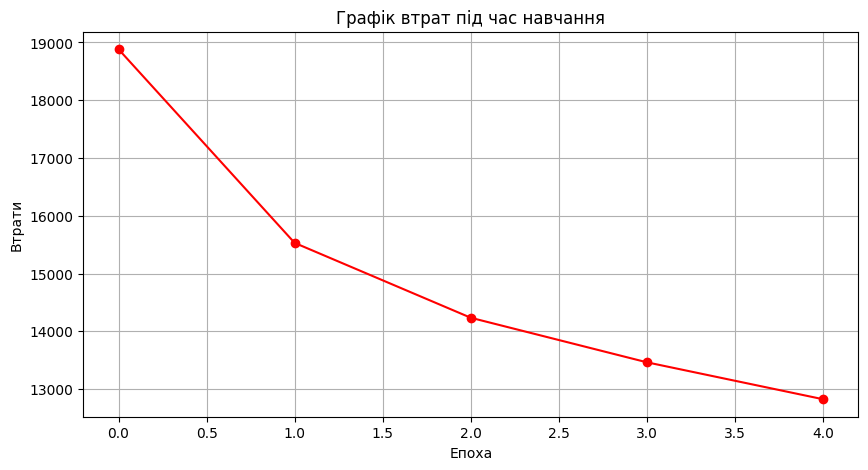

In [9]:
plt.figure(figsize=(10, 5))
plt.plot([i for i in range(len(losses))], losses, 'r-o')
plt.xlabel('Епоха')
plt.ylabel('Втрати')
plt.title('Графік втрат під час навчання')
plt.grid()
plt.show()

In [10]:
from IPython.display import Markdown as md
md(f""" 
|Метрика|Значення|
|-|-|
|Accuracy|{(correct * 100) / total}%|
|Loss|{(len(mis) * 100) / total}%|
""")

 
|Метрика|Значення|
|-|-|
|Accuracy|61.28%|
|Loss|38.72%|


In [ ]:
import torchvision.models as models


resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_features = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_features, 10)

optimizer = torch.optim.Adam(resnet18.fc.parameters(), lr=0.001)
epochs = 5
losses = []

for epoch in range(epochs):
    total_loss = 0.0 
    for images, labels in train_loader:
        optimizer.zero_grad()
        output = resnet18(images)
        loss = loss_f(output, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    losses.append(total_loss)
    print(f"Epoch: {epoch+1}, Loss: {total_loss}")

Epoch: 1, Loss: 26267.056909918785


KeyboardInterrupt: 

## Завдання 4
Оформіть результати в таблиці:

|Модель|Попередньо навчена|Accuracy|Loss|
|-|-|-|-|
|LeNet|Ні|-|-|
|ResNet18|Так|-|-|